## 0. Tiền xử lý dữ liệu

Import các thư viện cần thiết để xử lý dữ liệu

In [1]:
import os
import gc
import dask
import xarray as xr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
FOLDER_PATH = "../data/merged"

Gọi hàm con để xử lý dữ liệu thô được lấy từ ERA5

In [2]:
def preprocess(ds):
    if 'valid_time' in ds.coords: 
        ds = ds.rename({'valid_time': 'time'})
    if 'expver' in ds.dims: 
        ds = ds.mean(dim='expver')
    return ds.sortby('time')

Xử lý dữ liệu và nhóm các biến theo các danh mục khác nhau. Trong số này:
- daily_tr: Tốc độ dòng chảy bề mặt (toàn bộ nước chảy ra khỏi đất)
- daily_sr: Nước chảy trên bề mặt trước khi thấm xuống đất (góp phần tạo lũ)
- daily_ssr: Nước thấm xuống đất rồi tiếp tục xuống tầng sâu (tạo dòng nền)
- daily_sf: Tỉ lệ dòng chảy mặt
- daily_ssf: Tỉ lệ dòng chảy ngầm
- monthly_tr, monthly_sr, monthly_ssr: Các chỉ số theo tháng
- clim_tr, clim_sr, clim_ssr: Các chỉ số của từng tháng
- anom_tr: Chỉ số dị thường hàng ngày

In [3]:
def get_runoff_drainage_data_optimized(folder_path, runoff_name, s_runoff_name, ss_runoff_name):
    # Load datasets
    ds_tr = preprocess(xr.open_dataset(os.path.join(folder_path, runoff_name)))
    ds_sr = preprocess(xr.open_dataset(os.path.join(folder_path, s_runoff_name)))
    ds_ssr = preprocess(xr.open_dataset(os.path.join(folder_path, ss_runoff_name)))

    # Extract variables safely
    var_tr = list(ds_tr.data_vars)[0]
    var_sr = list(ds_sr.data_vars)[0]
    var_ssr = list(ds_ssr.data_vars)[0]

    # From Xarray DataSet to DataArray
    tr = ds_tr[var_tr]
    sr = ds_sr[var_sr]
    ssr = ds_ssr[var_ssr]

    # Spatial mean reduction
    tr = tr.mean(dim=['latitude', 'longitude'])
    sr = sr.mean(dim=['latitude', 'longitude'])
    ssr = ssr.mean(dim=['latitude', 'longitude'])

    # Aggregation to daily
    daily_tr = (tr * 86400).resample(time="1D").mean()
    daily_sr = (sr * 86400).resample(time="1D").mean()
    daily_ssr = (ssr * 86400).resample(time="1D").mean()

    # Compute at this time to maximize laziness
    daily_tr, daily_sr, daily_ssr = dask.compute(daily_tr, daily_sr, daily_ssr)

    # Close datasets
    ds_tr.close()
    ds_sr.close()
    ds_ssr.close()

    # Create derived variables
    daily_sf = daily_sr  / (daily_tr  + 1e-9)   # surface fraction (0–1)
    daily_ssf = daily_ssr / (daily_tr  + 1e-9)   # sub_surface fraction (0-1)

    # Create monthly figures
    monthly_tr = daily_tr.resample(time="1ME").mean()
    monthly_sr = daily_sr.resample(time="1ME").mean()
    monthly_ssr = daily_ssr.resample(time="1ME").mean()

    # Create climatology figures
    clim_tr = daily_tr.groupby("time.month").mean("time")
    clim_sr = daily_sr.groupby("time.month").mean("time")
    clim_ssr = daily_ssr.groupby("time.month").mean("time")

    # Create anomalies figures
    anom_tr = daily_tr.groupby("time.month") - clim_tr

    # Group 1D DataArray into a Dataset, then convert the whole to Pandas DataFrame
    df_daily = xr.Dataset({
        "tr": daily_tr,
        "sr": daily_sr,
        "ssr": daily_ssr,
        "sf": daily_sf,
        "ssf": daily_ssf,
        "anom_tr": anom_tr
    }).to_dataframe()

    df_monthly = xr.Dataset({
        "tr": monthly_tr,
        "sr": monthly_sr,
        "ssr": monthly_ssr
    }).to_dataframe()

    df_clim = xr.Dataset({
        "tr": clim_tr,
        "sr": clim_sr,
        "ssr": clim_ssr
    }).to_dataframe()

    gc.collect()

    return df_daily, df_monthly, df_clim

In [4]:
df_daily, df_monthly, df_clim = get_runoff_drainage_data_optimized(
    FOLDER_PATH, "mean_runoff_rate_merged.nc", "mean_surface_runoff_rate_merged.nc", "mean_sub_surface_runoff_rate_merged.nc")

In [5]:
df_daily = df_daily.drop(columns=['number']).reset_index()
df_daily.head()

,time,tr,sr,ssr,sf,ssf,month,anom_tr
0,1980-01-01,0.225810,0.001393,0.224305,0.006170,0.993338,1,-0.108936
1,1980-01-02,0.219171,0.000405,0.218605,0.001847,0.997421,1,-0.115575
2,1980-01-03,0.214008,0.000741,0.212959,0.003462,0.995101,1,-0.120738
3,1980-01-04,0.244800,0.037013,0.207745,0.151195,0.848631,1,-0.089946
4,1980-01-05,0.231416,0.028109,0.203046,0.121466,0.877408,1,-0.103330


In [6]:
df_monthly = df_monthly.drop(columns=['number']).reset_index()
df_monthly.head()

,time,tr,sr,ssr
0,1980-01-31,0.188634,0.020002,0.168608
1,1980-02-29,0.139534,0.033584,0.105862
2,1980-03-31,0.127593,0.056444,0.071464
3,1980-04-30,0.166081,0.119834,0.046460
4,1980-05-31,0.663717,0.579314,0.084413


In [7]:
df_clim = df_clim.drop(columns=['number']).reset_index()
df_clim.head()

,month,tr,sr,ssr
0,1,0.334746,0.047053,0.287622
1,2,0.201406,0.037109,0.164270
2,3,0.180539,0.077018,0.103640
3,4,0.277360,0.193846,0.083681
4,5,0.690209,0.540963,0.149272


## 1. Phân tích tốc độ dòng chảy bề mặt theo tháng

Trong khí hậu gió mùa, ta thường thấy dòng chảy bề mặt tăng mạnh vào mùa mưa, khi lượng mưa quá lớn so với khả năng hấp thụ. Trong khi đó, dòng chảy ngầm tăng từ từ hơn và cũng giảm từ từ hơn vào mùa khô. 

Thời điểm dòng chảy ngầm lớn hơn dòng chảy bề mặt là thời điểm chuyển giao từ trạng thái thuỷ văn do lũ chi phối sang trạng thái do dòng chảy nền chi phối.

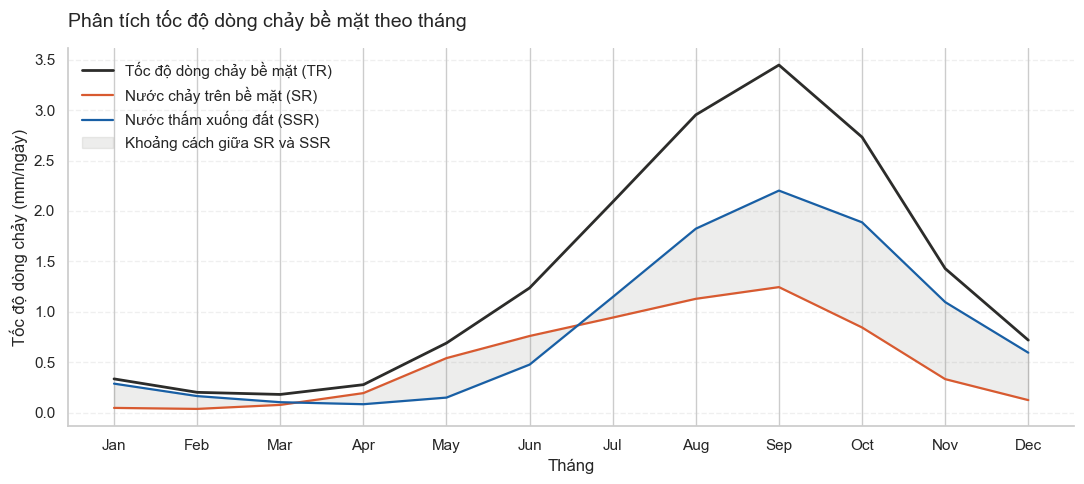

In [8]:
# Prepare data from your df_clim
months = df_clim['month'].values
mon_lbls = ["Jan","Feb","Mar","Apr","May","Jun",
             "Jul","Aug","Sep","Oct","Nov","Dec"]

# Extract values for plotting
clim_tr = df_clim['tr']
clim_sr = df_clim['sr']
clim_ssr = df_clim['ssr']

fig, ax = plt.subplots(figsize=(11, 5), dpi=100)

# Plot the three components
ax.plot(months, clim_tr, label="Tốc độ dòng chảy bề mặt (TR)", color="#2C2C2A", linewidth=2.0, zorder=3)
ax.plot(months, clim_sr, label="Nước chảy trên bề mặt (SR)", color="#D85A30", linewidth=1.6, zorder=2)
ax.plot(months, clim_ssr, label="Nước thấm xuống đất (SSR)", color="#185FA5", linewidth=1.6, zorder=2)

# Fill between Surface and Subsurface to highlight the partitioning/crossover
ax.fill_between(months, clim_sr, clim_ssr,
                alpha=0.15, color="#888780", label="Khoảng cách giữa SR và SSR")

# Styling
ax.set_title("Phân tích tốc độ dòng chảy bề mặt theo tháng", fontsize=14, loc='left', pad=15)
ax.set_xticks(months)
ax.set_xticklabels(mon_lbls)
ax.set_ylabel("Tốc độ dòng chảy (mm/ngày)", fontsize=12)
ax.set_xlabel("Tháng", fontsize=12)

# Add a grid for readability
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Place legend
ax.legend(frameon=False, loc='upper left')

plt.tight_layout()
plt.show()

## 2. Xu hướng phân chia dòng chảy

Xu hướng phân chia giữa dòng chảy bề mặt và dòng chảy ngầm qua từng năm được đo trong suốt 45 năm. Những năm nào mà dòng chảy bề mặt lớn hơn nhiều so với dòng chảy ngầm là những năm có nhiều nguy cơ lũ lụt mạnh hơn.

Ngược lại, những năm còn lại là những năm tốt cho dòng nước ngầm và ít khả năng lũ lụt hơn.

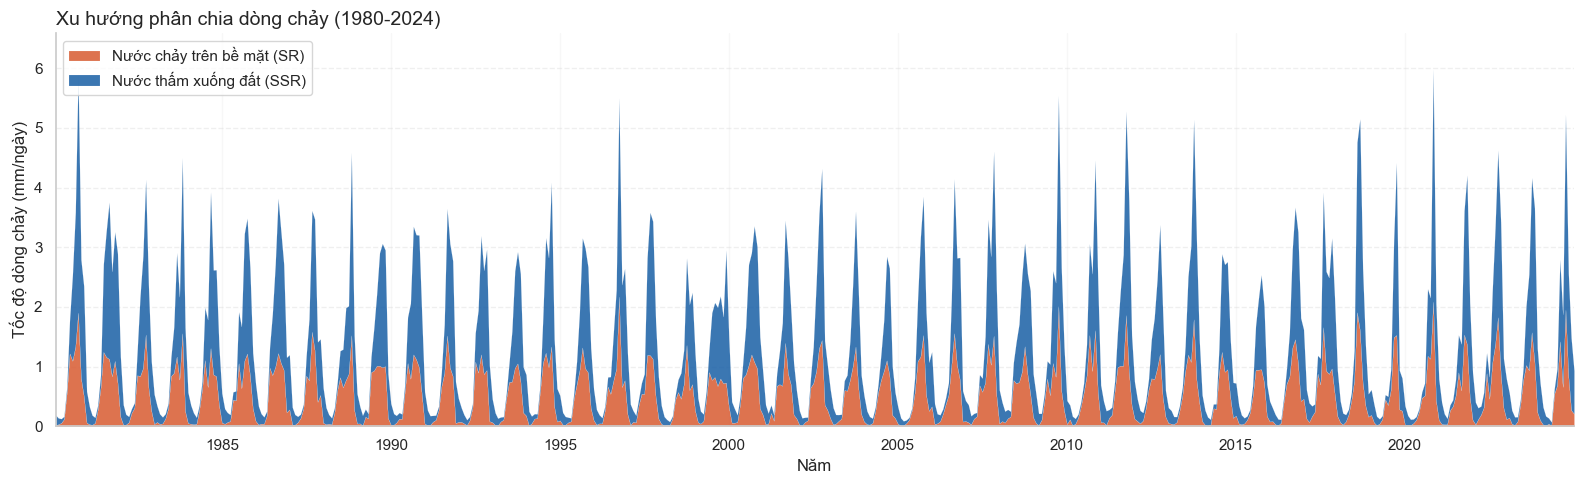

In [9]:
# Ensure the time column is in datetime format
df_monthly['time'] = pd.to_datetime(df_monthly['time'])

fig, ax = plt.subplots(figsize=(16, 5))

# Create the stacked area chart
# Order: SR on bottom (warm), SSR on top (cool)
ax.stackplot(df_monthly['time'], 
             df_monthly['sr'], 
             df_monthly['ssr'],
             labels=["Nước chảy trên bề mặt (SR)", "Nước thấm xuống đất (SSR)"],
             colors=["#D85A30", "#185FA5"],
             alpha=0.85,
             edgecolor='white',
             linewidth=0.1)

# Formatting the X-axis for a 45-year span
ax.xaxis.set_major_locator(mdates.YearLocator(5)) # Tick every 5 years
ax.xaxis.set_minor_locator(mdates.YearLocator(1)) # Tick every year
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Styling
ax.set_title("Xu hướng phân chia dòng chảy (1980-2024)", fontsize=14, loc='left')
ax.set_ylabel("Tốc độ dòng chảy (mm/ngày)", fontsize=12)
ax.set_xlabel("Năm", fontsize=12)
ax.set_xlim(df_monthly['time'].min(), df_monthly['time'].max())
ax.set_ylim(0, df_monthly['tr'].max() * 1.1) # Add 10% headroom

# Add grid for decadal tracking
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.grid(axis='x', which='major', linestyle='-', alpha=0.15)

# Place legend
ax.legend(loc="upper left", frameon=True, facecolor='white', framealpha=0.8)

# Remove top/right spines for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 3. Xu hướng lâu dài của tỉ lệ nước bề mặt

Khi tỉ lệ này tăng lên qua các năm, thì lượng lớn nước mưa đang chảy tràn qua mặt đất và không thể ngấm xuống dưới lòng đất. Khu vực này qua các năm sẽ dễ bị lũ lụt hơn, và khó có thể phục hồi mạch nước ngầm.

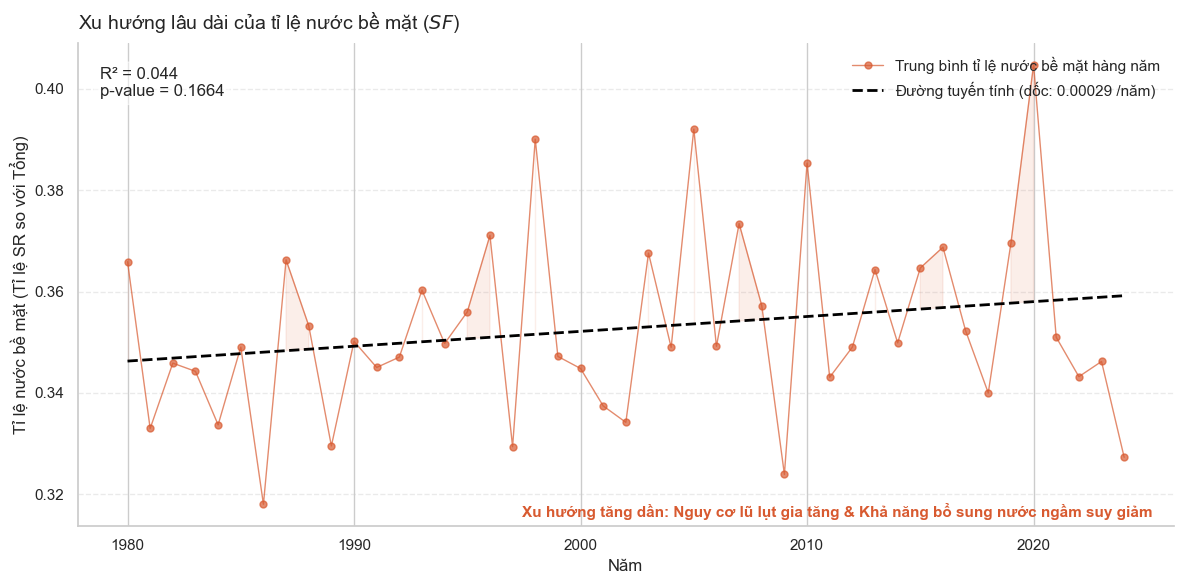

In [ ]:
# Prepare Annual Data
df_daily['time'] = pd.to_datetime(df_daily['time'])
annual_sf = df_daily.groupby(df_daily['time'].dt.year)['sf'].mean()
years = annual_sf.index.values
values = annual_sf.values

# Calculate Linear Trend
slope, intercept, r_value, p_value, std_err = stats.linregress(years, values)
trend_line = intercept + slope * years

fig, ax = plt.subplots(figsize=(12, 6))

# Plot the annual means
ax.plot(years, values, marker='o', markersize=5, color='#D85A30', 
        linestyle='-', linewidth=1, alpha=0.7, label="Trung bình tỉ lệ nước bề mặt hàng năm")

# Plot the trend line
ax.plot(years, trend_line, color='black', linestyle='--', linewidth=2, 
        label=f"Đường tuyến tính (dốc: {slope:.5f} /năm)")

# Add a confidence interval or highlight the trend direction
if slope > 0:
    ax.fill_between(years, trend_line, values, where=(values > trend_line), 
                    color='#D85A30', alpha=0.1)
    status_msg = "Xu hướng tăng dần: Nguy cơ lũ lụt gia tăng & Khả năng bổ sung nước ngầm suy giảm"
else:
    status_msg = "Xu hướng giảm dần: Tăng khả năng thấm nước của đất"

# Styling
ax.set_title("Xu hướng lâu dài của tỉ lệ nước bề mặt ($SF$)", fontsize=14, loc='left', pad=10)
ax.set_ylabel("Tỉ lệ nước bề mặt (Tỉ lệ SR so với Tổng)", fontsize=12)
ax.set_xlabel("Năm", fontsize=12)

# Annotation for policy relevance
stats_text = f"R² = {r_value**2:.3f}\np-value = {p_value:.4f}"
ax.text(0.02, 0.95, stats_text, transform=ax.transAxes, verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

ax.text(0.98, 0.02, status_msg, transform=ax.transAxes, horizontalalignment='right', 
        fontsize=11, fontweight='bold', color='#D85A30' if slope > 0 else '#185FA5')

# Final formatting
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right', frameon=False)

plt.tight_layout()
plt.show()

## 4. Heatmap dị thường tốc độ dòng chảy bề mặt

Heatmap này đo dị thường trong tốc độ dòng chảy bề mặt qua từng tháng một trong suốt 45 năm. Ta thấy được vào mùa khô, đất có xu hướng thấm nước bề mặt tốt hơn là vào mùa mưa, hoặc đơn giản chỉ là lượng mưa ít hơn.

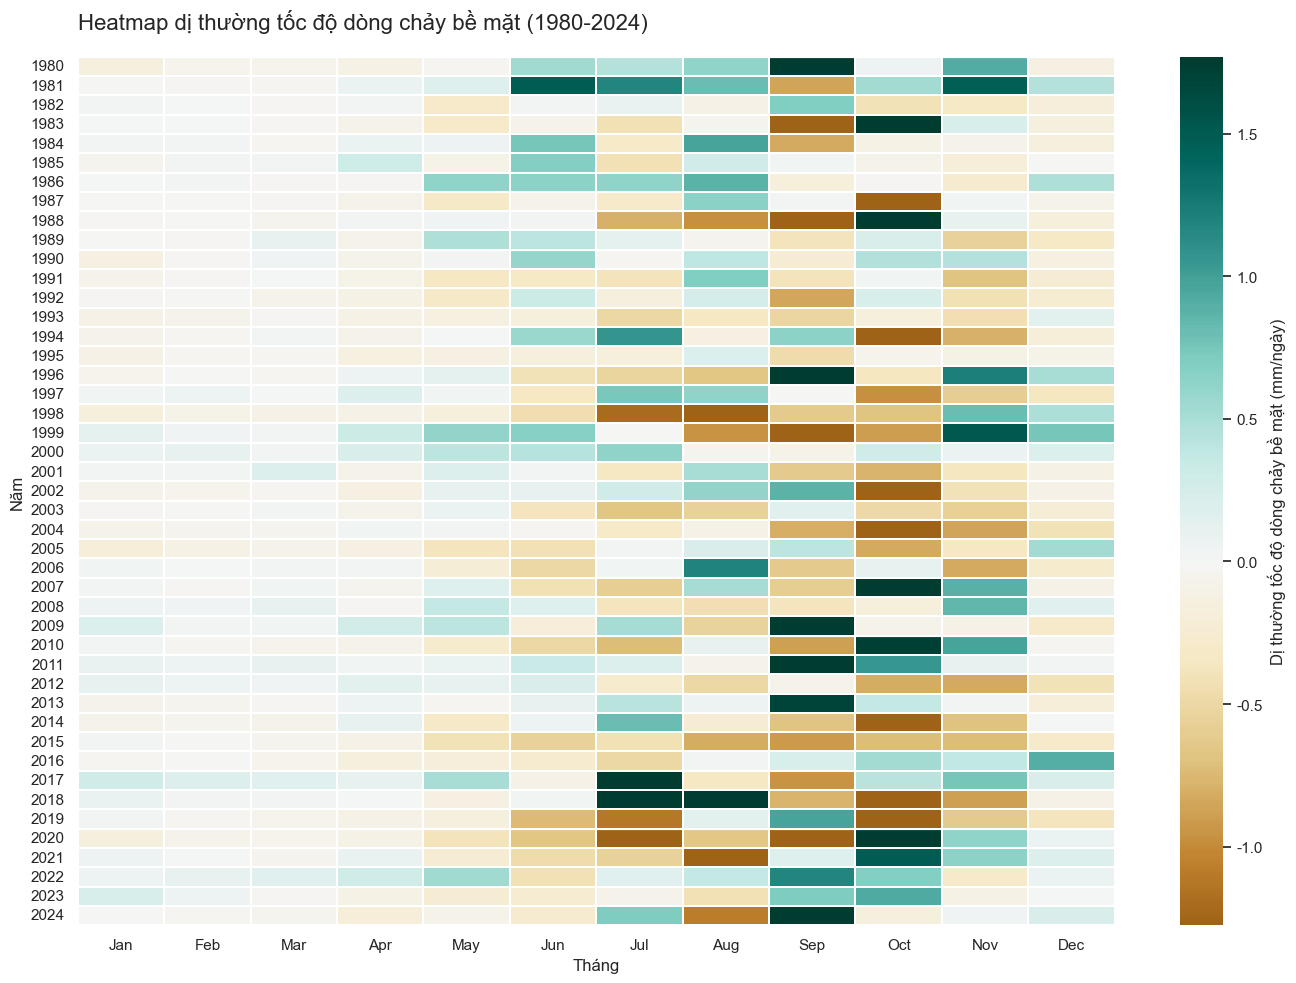

In [13]:
# Ensure time is datetime and extract Year
df_daily['time'] = pd.to_datetime(df_daily['time'])
df_daily['year'] = df_daily['time'].dt.year

# Create the pivot table: Mean anomaly per month per year
# (If your df_daily already has 'anom_tr', we aggregate it to monthly scale)
pivot_anom = df_daily.pivot_table(index='year', 
                                  columns='month', 
                                  values='anom_tr', 
                                  aggfunc='mean')

fig, ax = plt.subplots(figsize=(14, 10))

# Using BrBG (Brown to Blue-Green) is standard for hydrology:
# Brown = Drought/Low Runoff; Blue = Excess Runoff/Flood potential
sns.heatmap(pivot_anom, 
            cmap='BrBG', 
            center=0, 
            robust=True,
            cbar_kws={'label': 'Dị thường tốc độ dòng chảy bề mặt (mm/ngày)'},
            linewidths=0.05,
            ax=ax)

# Styling
mon_lbls = ["Jan","Feb","Mar","Apr","May","Jun",
            "Jul","Aug","Sep","Oct","Nov","Dec"]

ax.set_title("Heatmap dị thường tốc độ dòng chảy bề mặt (1980-2024)", fontsize=16, loc='left', pad=20)
ax.set_xticklabels(mon_lbls)
ax.set_ylabel("Năm", fontsize=12)
ax.set_xlabel("Tháng", fontsize=12)

# Optional: Add borders around specific decades for better visual tracking
for i in range(0, len(pivot_anom), 10):
    ax.axhline(i, color='white', lw=1, alpha=0.5)

plt.tight_layout()
plt.show()

## 5. Dấu hiệu tần suất dòng chảy cực đoan

Đếm số ngày trong năm khi mà dòng chảy bề mặt lớn hơn phân vị thứ 95 trong suốt phân bố 45 năm. Ta làm tương tự với chỉ số dòng chảy ngầm.

Tần suất dòng chảy bề mặt tăng có nghĩa là tăng mạnh nguy cơ lũ lụt. Ngược lại, tần suất dòng chảy ngầm tăng sẽ giúp tăng khả năng phục hồi mạch nước ngầm (đây thường là tín hiệu khả quan).

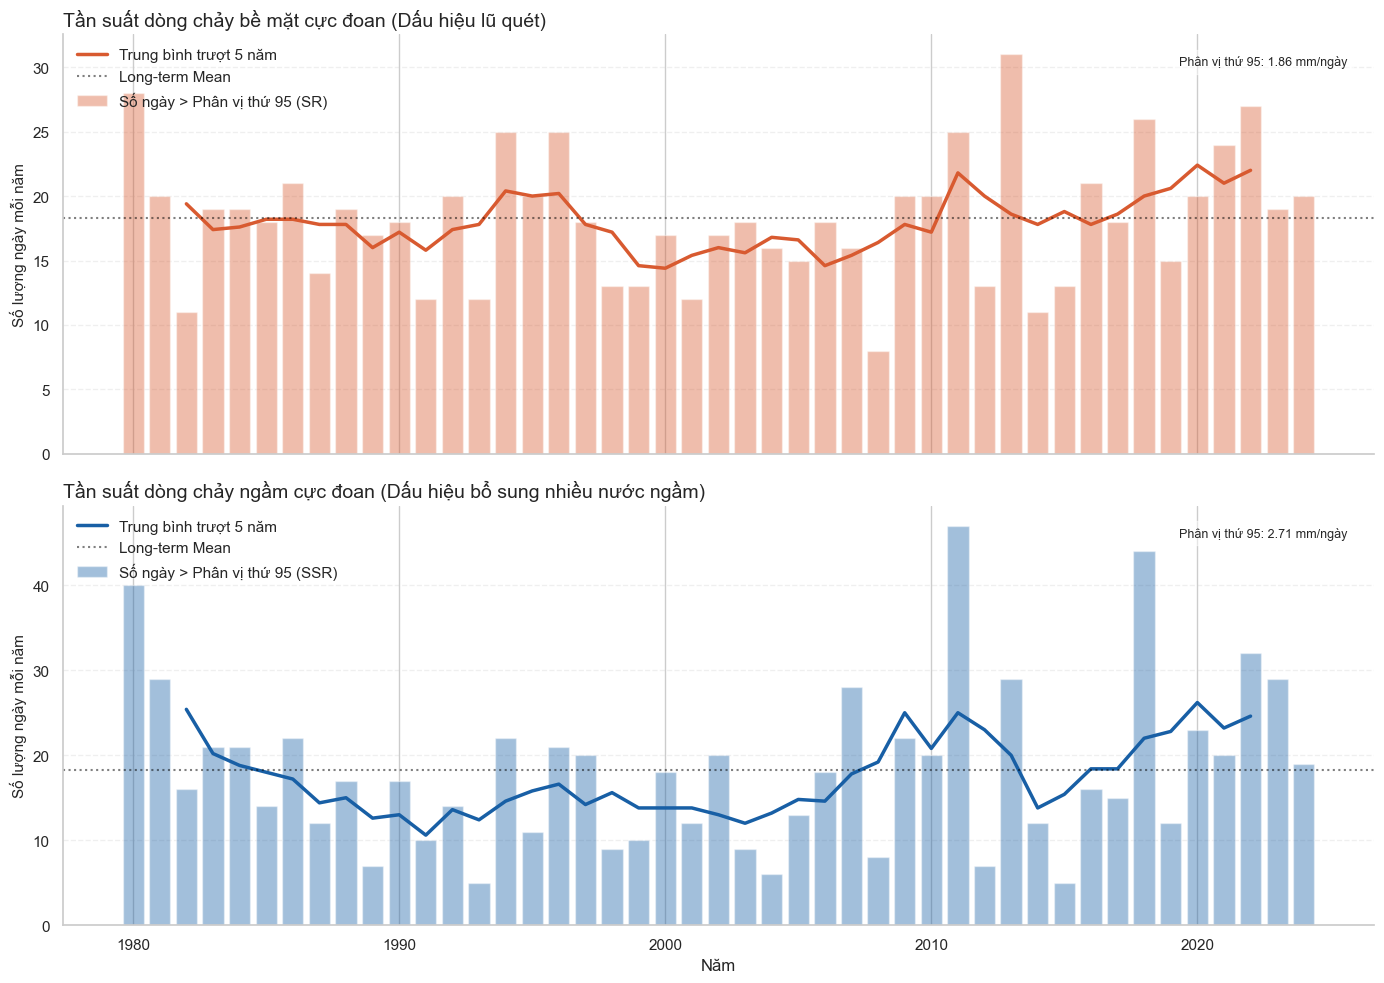

In [ ]:
# Calculate the 95th percentile thresholds
q95_sr = df_daily['sr'].quantile(0.95)
q95_ssr = df_daily['ssr'].quantile(0.95)

# Identify extreme days and aggregate by year
df_daily['time'] = pd.to_datetime(df_daily['time'])
df_daily['is_extreme_sr'] = df_daily['sr'] > q95_sr
df_daily['is_extreme_ssr'] = df_daily['ssr'] > q95_ssr

annual_extremes = df_daily.groupby(df_daily['time'].dt.year).agg({
    'is_extreme_sr': 'sum',
    'is_extreme_ssr': 'sum'
}).rename(columns={'is_extreme_sr': 'SR_count', 'is_extreme_ssr': 'SSR_count'})

# Calculate 5-year rolling means
annual_extremes['SR_rolling'] = annual_extremes['SR_count'].rolling(window=5, center=True).mean()
annual_extremes['SSR_rolling'] = annual_extremes['SSR_count'].rolling(window=5, center=True).mean()


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Subplot 1: Surface Runoff Extremes (Flash Flood Risk)
ax1.bar(annual_extremes.index, annual_extremes['SR_count'], 
        color='#D85A30', alpha=0.4, label='Số ngày > Phân vị thứ 95 (SR)')
ax1.plot(annual_extremes.index, annual_extremes['SR_rolling'], 
         color='#D85A30', linewidth=2.5, label='Trung bình trượt 5 năm')
ax1.axhline(annual_extremes['SR_count'].mean(), color='black', linestyle=':', alpha=0.5, label='Long-term Mean')

ax1.set_title("Tần suất dòng chảy bề mặt cực đoan (Dấu hiệu lũ quét)", fontsize=14, loc='left')
ax1.set_ylabel("Số lượng ngày mỗi năm", fontsize=11)
ax1.legend(loc='upper left', frameon=False)
ax1.text(0.98, 0.95, f"Phân vị thứ 95: {q95_sr:.2f} mm/ngày", transform=ax1.transAxes, ha='right', va='top', fontsize=9, bbox=dict(facecolor='white', alpha=0.5))

# Subplot 2: Subsurface Runoff Extremes (Groundwater Recharge)
ax2.bar(annual_extremes.index, annual_extremes['SSR_count'], 
        color='#185FA5', alpha=0.4, label='Số ngày > Phân vị thứ 95 (SSR)')
ax2.plot(annual_extremes.index, annual_extremes['SSR_rolling'], 
         color='#185FA5', linewidth=2.5, label='Trung bình trượt 5 năm')
ax2.axhline(annual_extremes['SSR_count'].mean(), color='black', linestyle=':', alpha=0.5, label='Long-term Mean')

ax2.set_title("Tần suất dòng chảy ngầm cực đoan (Dấu hiệu bổ sung nhiều nước ngầm)", fontsize=14, loc='left')
ax2.set_ylabel("Số lượng ngày mỗi năm", fontsize=11)
ax2.set_xlabel("Năm", fontsize=12)
ax2.legend(loc='upper left', frameon=False)
ax2.text(0.98, 0.95, f"Phân vị thứ 95: {q95_ssr:.2f} mm/ngày", transform=ax2.transAxes, ha='right', va='top', fontsize=9, bbox=dict(facecolor='white', alpha=0.5))

# Clean up layout
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()